<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [ ]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=dcf8a8dd-76db-4ff7-887b-cd5a40d182c4
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:07<00:00, 91.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 16.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 6.03MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 1.41MB/s]


Разархивируйте zip файл, где содержатся wav файлы датасета.

In [ ]:
!unzip /content/sound_classification_dataset.zip

Archive:  /content/sound_classification_dataset.zip
replace content/sound_classification_dataset/1-61261-A-44.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace content/sound_classification_dataset/2-104105-A-19.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
train_df

,filename,category
0,1-100032-A-0.wav,dog
1,1-110389-A-0.wav,dog
2,1-17367-A-10.wav,rain
3,1-187207-A-20.wav,crying_baby
4,1-211527-A-20.wav,crying_baby
...,...,...
115,3-170383-A-38.wav,clock_tick
116,3-171012-A-38.wav,clock_tick
117,3-171041-A-38.wav,clock_tick
118,3-180256-A-0.wav,dog


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

Перед тем, как создавать батчи, давайте узнаем, какова средняя длина аудио у данных. По результатам анализа определим конечное fixed_length_sec.

In [ ]:
import os
import torchaudio
import pandas as pd

all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

all_df['duration'] = all_df['filename'].apply(
    lambda f: (lambda waveform, sr: waveform.shape[1] / sr)(
        *torchaudio.load(os.path.join("content/sound_classification_dataset", f))
    )
)

print(all_df)

              filename     category  duration
0     1-100032-A-0.wav          dog       5.0
1     1-110389-A-0.wav          dog       5.0
2     1-17367-A-10.wav         rain       5.0
3    1-187207-A-20.wav  crying_baby       5.0
4    1-211527-A-20.wav  crying_baby       5.0
..                 ...          ...       ...
195  5-221518-A-21.wav          NaN       5.0
196  5-221593-A-21.wav          NaN       5.0
197   5-231762-A-0.wav          NaN       5.0
198  5-235671-A-38.wav          NaN       5.0
199     5-9032-A-0.wav          NaN       5.0

[200 rows x 3 columns]


In [ ]:
print(all_df['duration'].describe())

count    200.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: duration, dtype: float64


Создание датасета

In [ ]:
!pip install torch_audiomentations

In [ ]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
from torch_audiomentations import Compose, Gain, PolarityInversion, PitchShift

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, df, root_dir="content/sound_classification_dataset",
                 target_sr=16000, fixed_length_sec=5, do_augmentation=False):

        self.df = df
        self.root_dir = root_dir
        self.target_sr = target_sr
        self.fixed_length = fixed_length_sec * target_sr  # 5 * 16000 = 80000
        self.do_augmentation = do_augmentation

        self.categories = sorted(df['category'].unique())
        self.category_to_idx = {cat: idx for idx, cat in enumerate(self.categories)}

        if do_augmentation:
          self.augment = Compose([
              Gain(
                  min_gain_in_db=-15.0,
                  max_gain_in_db=5.0,
                  p=0.5,
                   ),
              PolarityInversion(p=0.5),
              # PitchShift(sample_rate=16000, min_transpose_semitones=-2, max_transpose_semitones=2, p=0.3),
          ])
        else:
            self.augment = None

    def __len__(self):
        return len(self.df)

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        """Resample audio to target sample rate."""
        if original_sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=self.target_sr)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        """Convert stereo to mono by averaging channels."""
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True) # если аудио в стерео, то усредняем каналы и получаем моно
        return signal

    def _cut_or_pad(self, signal):
        """Cut or pad signal to fixed length."""
        current_length = signal.shape[1]

        if current_length < self.fixed_length:
            # Padding
            padding = self.fixed_length - current_length
            signal = torch.nn.functional.pad(signal, (0, padding))
        elif current_length > self.fixed_length:
            # Cutting from the beginning
            signal = signal[:, :self.fixed_length]
        return signal

    def _augmentation(self, signal):
        # signal: [1, samples]
        signal = signal.unsqueeze(0)  # [1, 1, samples] — batch_size=1, channels=1
        signal = self.augment(signal, sample_rate=self.target_sr)
        signal = signal.squeeze(0)    # [1, samples]
        return signal

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filepath = os.path.join(self.root_dir, row['filename'])

        # Load audio
        waveform, sample_rate = torchaudio.load(filepath)

        # Preprocessing
        waveform = self._resample(waveform, sample_rate)
        waveform = self._stereo_to_mono(waveform)
        waveform = self._cut_or_pad(waveform)

        # Augmentation (if enabled)
        if self.do_augmentation and self.augment is not None:
            waveform = self._augmentation(waveform)

        # Get label
        label = self.category_to_idx[row['category']]

        return waveform, label  # waveform: [1, 80000]


### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

#### Модель 1 (Базовая модель)


In [ ]:
import torch.nn as nn

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms using 1D CNN (no BatchNorm, no Dropout)."""

    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, 32, kernel_size=80, stride=4),
            nn.ReLU(),
            nn.MaxPool1d(4),

            # Layer 2
            nn.Conv1d(32, 64, kernel_size=40, stride=2),
            nn.ReLU(),
            nn.MaxPool1d(4),

            # Layer 3
            nn.Conv1d(64, 128, kernel_size=20, stride=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x: [B, 1, 80000]
        x = self.classifier(self.features(x))
        return x

#### Модель 2 (Базовая модель + BatchNorm и Dropout)


In [ ]:
class SoundClassificatonModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=80, stride=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=40, stride=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=20, stride=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.classifier(self.features(x))
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [ ]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [ ]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).float().mean()

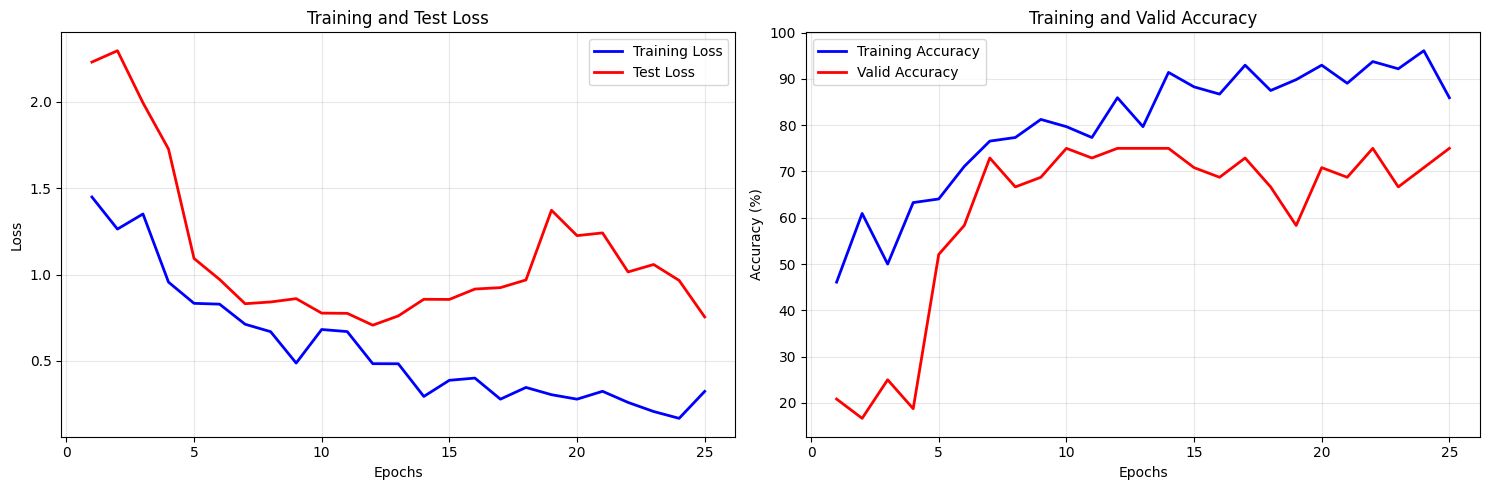

Epoch [25/25]
Train Loss: 0.3233, Train Acc: 85.94%
Valid Loss: 0.7545, Valid Acc: 75.00%


In [ ]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
import torch
import torch.nn as nn

train_dataset = SimpleAudioDataset(train_df, do_augmentation=True)
valid_dataset = SimpleAudioDataset(valid_df, do_augmentation=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=2)

# Модель
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Метрики для визуализации
train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

# Подсчет Acc
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).float().mean().item()

n_epochs = 25
for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss_epoch = 0.0
    train_acc_epoch = 0.0
    num_train_batches = 0

    for signals, labels in train_loader:
        signals = signals.to(device)
        labels = labels.to(device)

        outputs = model(signals)
        loss = criterion(outputs, labels)
        acc = calculate_accuracy(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()
        train_acc_epoch += acc
        num_train_batches += 1

    avg_train_loss = train_loss_epoch / num_train_batches
    avg_train_acc = train_acc_epoch / num_train_batches

    # Валидация
    model.eval()
    valid_loss_epoch = 0.0
    valid_acc_epoch = 0.0
    num_valid_batches = 0

    with torch.no_grad():
        for signals, labels in valid_loader:
            signals = signals.to(device)
            labels = labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)
            acc = calculate_accuracy(outputs, labels)

            valid_loss_epoch += loss.item()
            valid_acc_epoch += acc
            num_valid_batches += 1

    # Метрики
    avg_valid_loss = valid_loss_epoch / num_valid_batches
    avg_valid_acc = valid_acc_epoch / num_valid_batches

    # Метрики для визуализации
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc * 100)
    valid_losses.append(avg_valid_loss)
    valid_accuracies.append(avg_valid_acc * 100)

    if (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
        clear_output(wait=True)
        plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
        print(f"Epoch [{epoch + 1}/{n_epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc * 100:.2f}%")
        print(f"Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {avg_valid_acc * 100:.2f}%")

In [ ]:
# dropout = 0.3
print("Train Accuracy = ", avg_train_acc)
print("Valid Accuracy = ", avg_valid_acc)

Train Accuracy =  0.859375
Valid Accuracy =  0.75


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cpu
ESC-50 Audio Classification Demo!


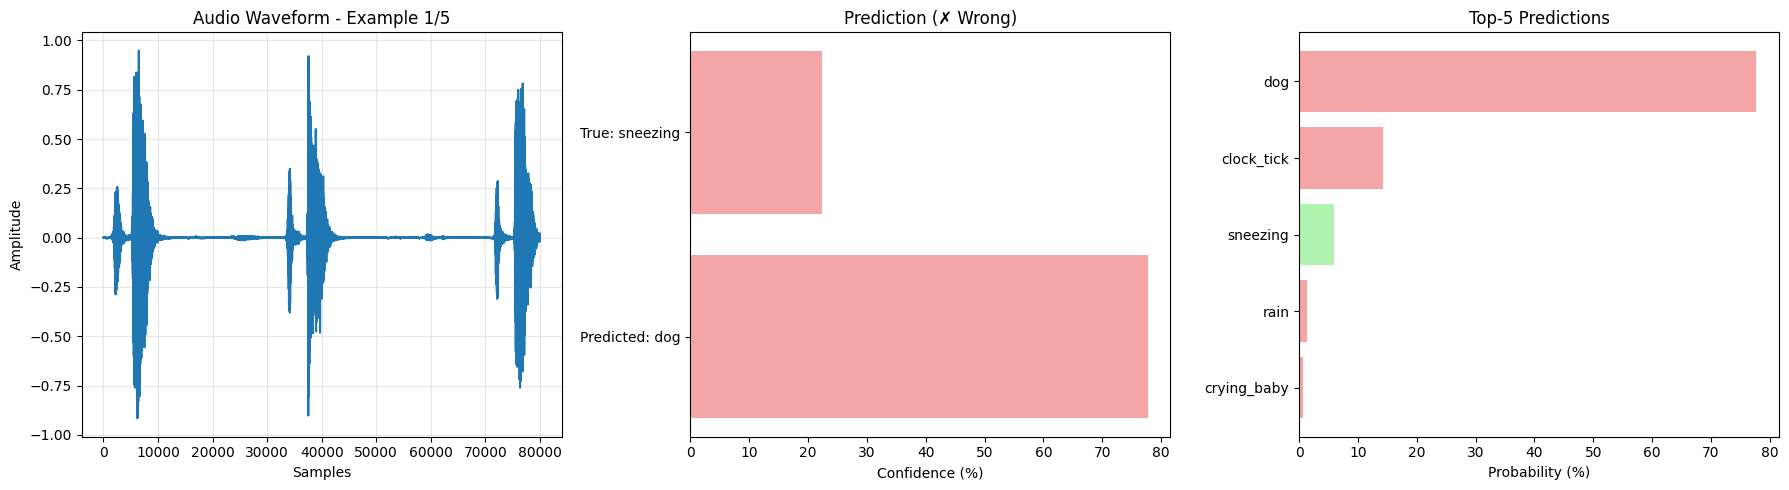

Playing: sneezing


Prediction: dog (77.71%)
True label: sneezing
Correct: False


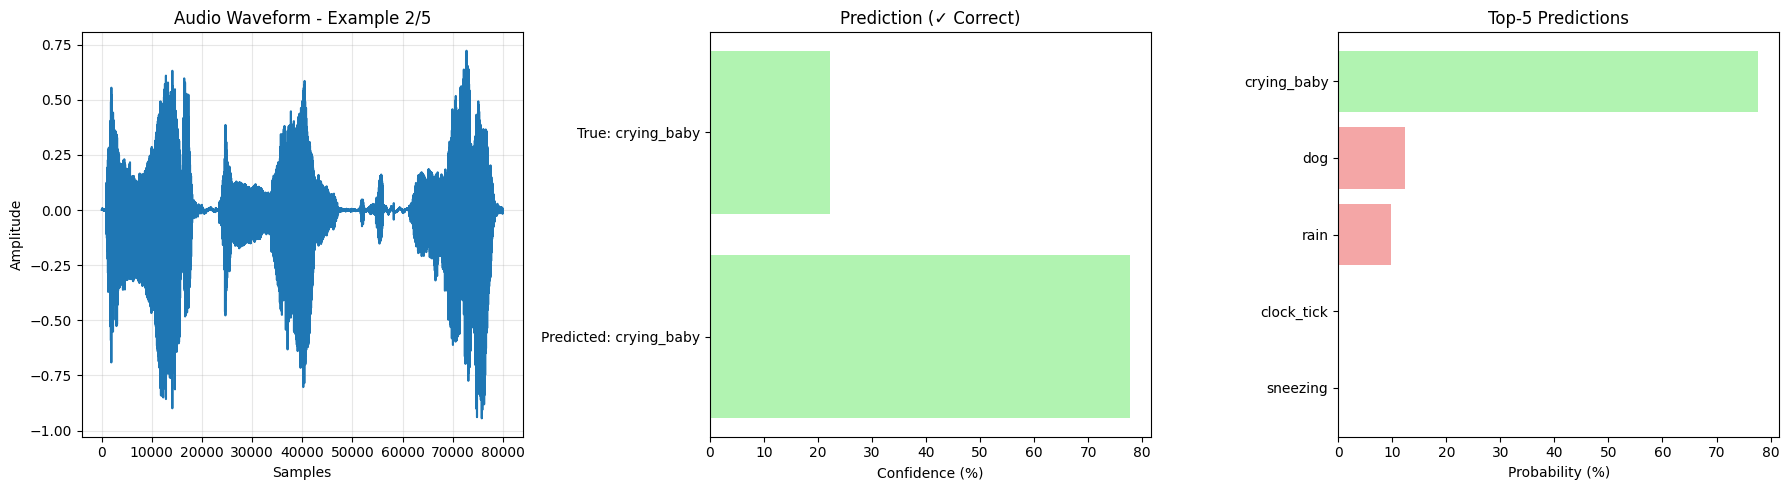

Playing: crying_baby


Prediction: crying_baby (77.75%)
True label: crying_baby
Correct: True


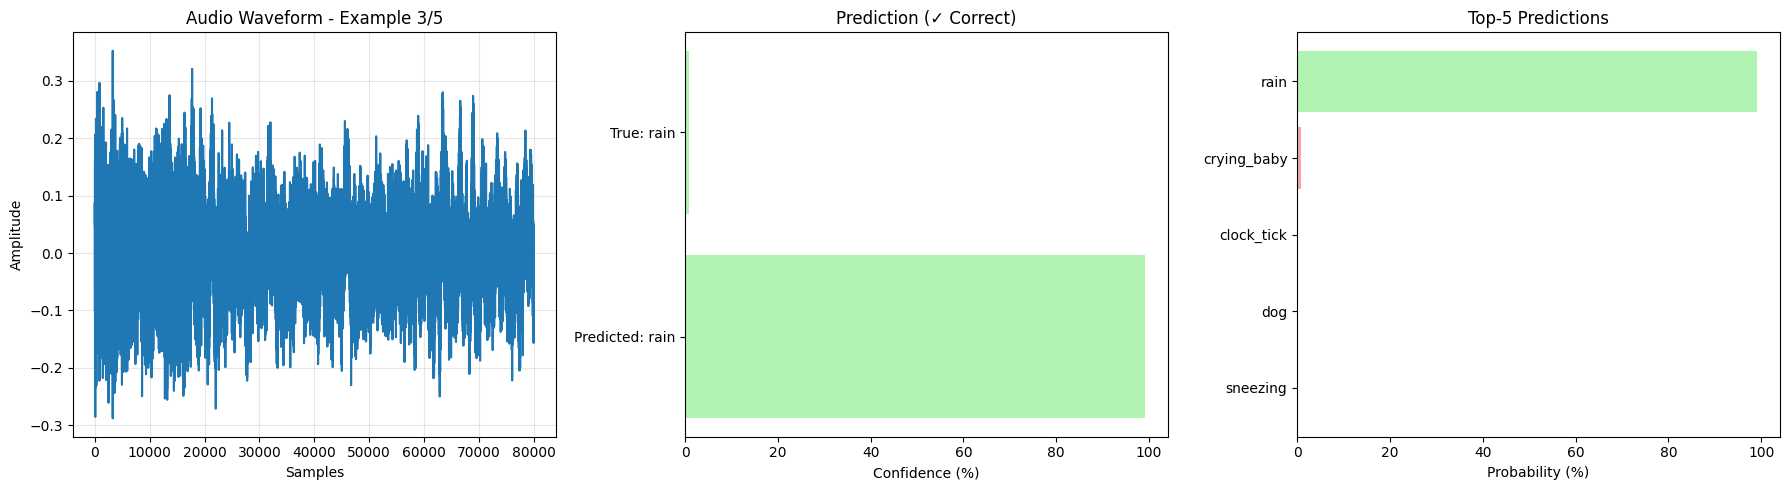

Playing: rain


Prediction: rain (99.08%)
True label: rain
Correct: True


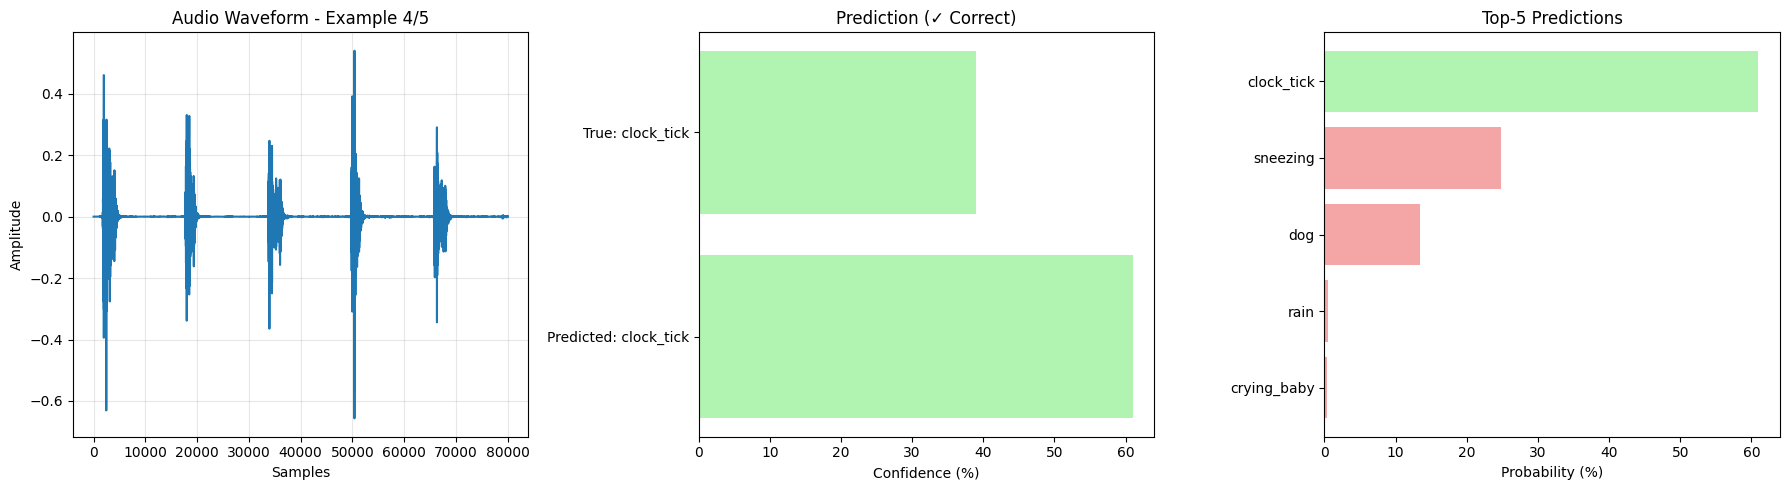

Playing: clock_tick


Prediction: clock_tick (60.98%)
True label: clock_tick
Correct: True


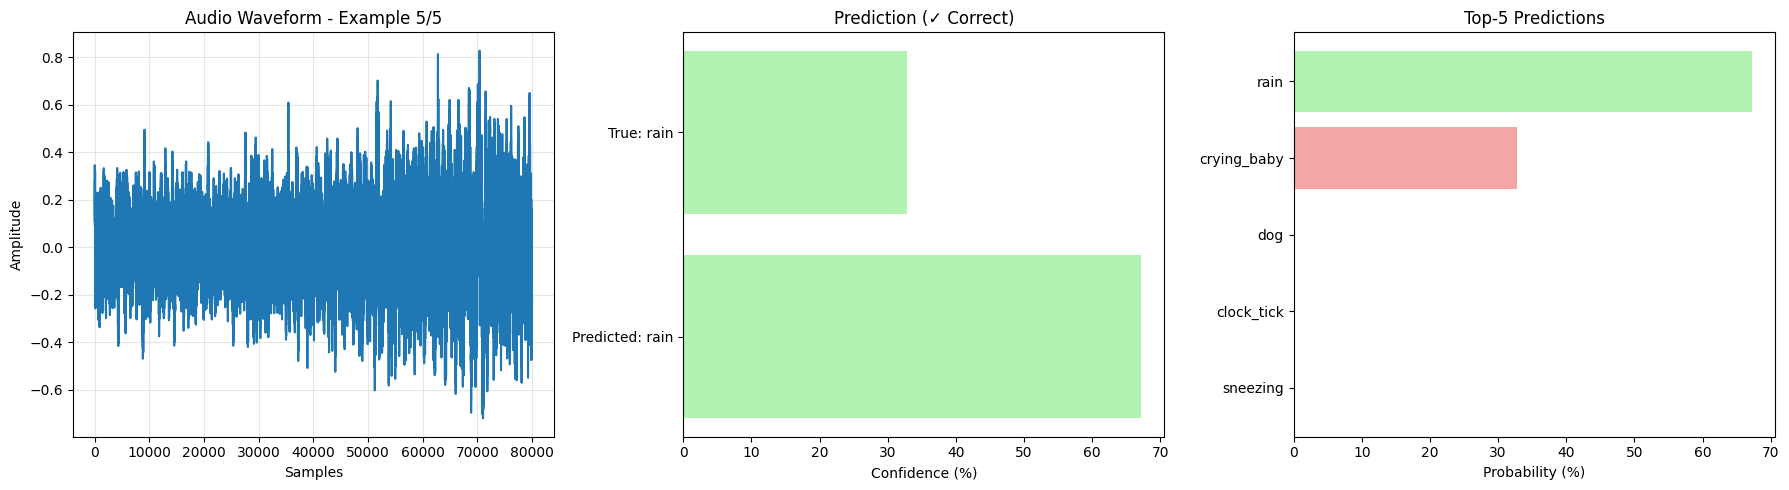

Playing: rain


Prediction: rain (67.22%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 30/40
Accuracy: 75.00%


In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = list(test_dataset.category_to_idx.keys())
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels
# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
test_df

,filename
0,5-151085-A-20.wav
1,5-181766-A-10.wav
2,5-187979-A-21.wav
3,5-188655-A-10.wav
4,5-193339-A-10.wav
5,5-194533-A-21.wav
6,5-194892-A-10.wav
7,5-195710-A-10.wav
8,5-198321-A-10.wav
9,5-198411-A-20.wav


In [ ]:
# 1. Добавляем dummy-метку
test_df = test_df.copy()
test_df['category'] = 'dog'  # временная заглушка

# 2. Создаём test_dataset с тем же маппингом классов, что и у train
test_dataset = SimpleAudioDataset(test_df, do_augmentation=False)

# 3. Но заменяем category_to_idx на обученный!
test_dataset.category_to_idx = train_dataset.category_to_idx
test_dataset.categories = train_dataset.categories

In [ ]:
test_dataset = SimpleAudioDataset(test_df, do_augmentation=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model.eval()
all_predictions = []

with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())

# Теперь all_predictions — список из 40 чисел (индексов классов)
print(f"Количество предсказаний: {len(all_predictions)}")
print(f"Первые 5 предсказаний: {all_predictions[:5]}")

Количество предсказаний: 40
Первые 5 предсказаний: [np.int64(1), np.int64(3), np.int64(4), np.int64(3), np.int64(3)]


In [ ]:
idx_to_category = {idx: cat for cat, idx in test_dataset.category_to_idx.items()}
y_test_pred = [idx_to_category[idx] for idx in all_predictions]

KeyError: np.int64(1)

In [ ]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.


Модель 1


***Базовая модель***

**Аугментации**:

* Gain(min_gain_in_db=-15.0, max_gain_in_db=5.0, p=0.5)

Gain моделирует изменение громкости записи — от тихого (–15 дБ) до умеренно громкого (+5 дБ). Это реалистичный диапазон для бытовых записей и помогает модели стать инвариантной к уровню громкости.

* PolarityInversion(p=0.5)

PolarityInversion просто инвертирует знак сигнала (x → –x). Поскольку человеческое ухо не чувствительно к полярности, такая аугментация безопасна и увеличивает разнообразие данных без искажения семантики.

**Результаты**: Train Acc = 92.22%, Val Acc = 64.58%

**Выводы**: Произошло классическое переобучение: модель прекрасно справляется с тренировочными данными, но все хуже и хуже с валидационными.

Модель 2

***Базовая модель + BatchNorm + Dropout***

* Добавлен BatchNorm1d после каждого свёрточного слоя — стабилизирует распределение активаций, ускоряет обучение и снижает внутренний ковариатный сдвиг.
* Добавлен Dropout(c 0.5 до 0.3) перед финальным классификатором — случайно обнуляет 30% нейронов, заставляя сеть не полагаться на отдельные признаки и лучше обобщать.


**Аугментации**:

те же

**Результаты**: Train Acc = 92.97% Val Acc = 72.92%

**Выводы**: Добавление регуляризации значительно снизило переобучение: точность на валидации возросла.

Модель 3

***Базовая модель + BatchNorm + Dropout + PitchShift (Augmentation) + AddColoredNoise (Augmentation)***

**Аугментации**:

те же + PitchShift(sample_rate=16000, min_transpose_semitones=-2, max_transpose_semitones=2, p=0.5)

Мне захотелось сделать модель более инвариантной к высоте тона, что полезно, например, для голоса или лая. Диапазон ±2 полутона выбран как умеренный. Вероятность p=0.5 означает, что половина батча подвергается pitch-сдвигу

**Результаты**: Train Acc = 87.50% Val Acc = 62.50%

**Выводы**: Добавление PitchShift ухудшило качество модели. Вероятно, это связано с тем, что изменение высоты тона искажает семантику (что становится излишним) некоторых классов: например, плач ребёнка или лай собаки. На малом датасете такие аугментации оказались избыточными.


По итогу была выбрана Модель 2 и точность попадания составила у нее 75 процента (30/40 на тесте)